# IMPORT

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from collections import deque
import random
import math

## Bài 2 – Multiscale Hough Transform

### 2.1 Xây accumulator Hough từ đầu với ít nhất hai mức phân giải (coarse và fine)

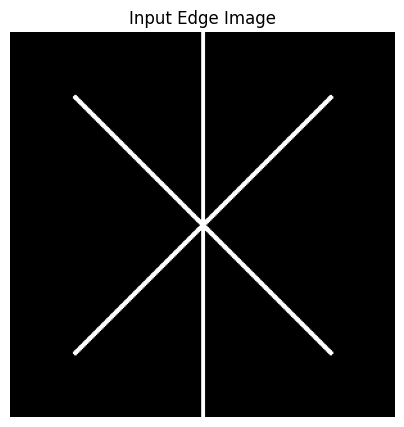

Coarse Accumulator Shape:
(108, 45)
Fine Accumulator Shape:
(426, 180)


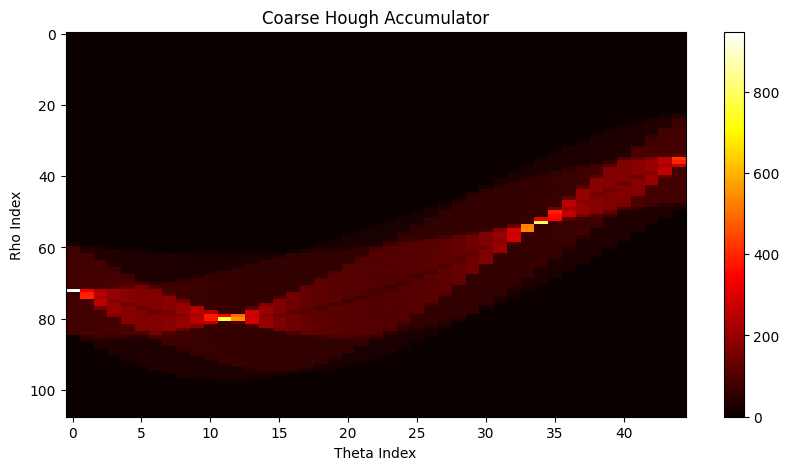

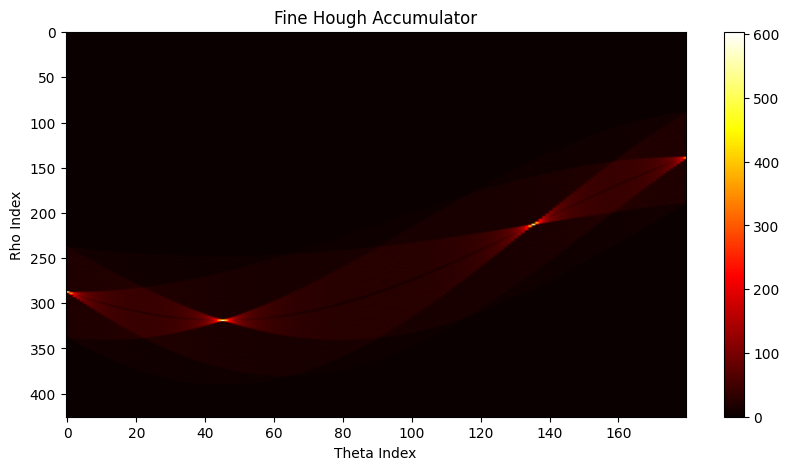

In [4]:

import numpy as np
import cv2
import matplotlib.pyplot as plt

# TẠO ẢNH TEST

img = np.zeros((300, 300), dtype=np.uint8)

# Đường chéo 1
cv2.line(img, (50, 50), (250, 250), 255, 2)

# Đường chéo 2
cv2.line(img, (50, 250), (250, 50), 255, 2)

# Đường thẳng đứng
cv2.line(img, (150, 0), (150, 299), 255, 2)

edges = img.copy()

plt.figure(figsize=(5,5))
plt.imshow(edges, cmap='gray')
plt.title("Input Edge Image")
plt.axis('off')
plt.show()


# HÀM XÂY Hough Accumulator

def build_hough_accumulator(edges, rho_res, theta_res):

    height, width = edges.shape

    diag_len = int(np.ceil(np.sqrt(height**2 + width**2)))

    rhos = np.arange(
        -diag_len,
        diag_len + rho_res,
        rho_res
    )

    thetas = np.deg2rad(
        np.arange(0, 180, theta_res)
    )

    accumulator = np.zeros(
        (len(rhos), len(thetas)),
        dtype=np.uint64
    )

    y_idxs, x_idxs = np.nonzero(edges)

    for x, y in zip(x_idxs, y_idxs):

        for theta_idx, theta in enumerate(thetas):

            rho = x * np.cos(theta) + y * np.sin(theta)

            rho_idx = np.argmin(
                np.abs(rhos - rho)
            )

            accumulator[rho_idx, theta_idx] += 1

    return accumulator, rhos, thetas


# COARSE ACCUMULATOR

acc_coarse, rhos_c, thetas_c = build_hough_accumulator(
    edges,
    rho_res=8,
    theta_res=4
)

print("Coarse Accumulator Shape:")
print(acc_coarse.shape)


# FINE ACCUMULATOR

acc_fine, rhos_f, thetas_f = build_hough_accumulator(
    edges,
    rho_res=2,
    theta_res=1
)

print("Fine Accumulator Shape:")
print(acc_fine.shape)


# HIỂN THỊ COARSE

plt.figure(figsize=(10,5))
plt.imshow(
    acc_coarse,
    cmap='hot',
    aspect='auto'
)

plt.title("Coarse Hough Accumulator")
plt.xlabel("Theta Index")
plt.ylabel("Rho Index")
plt.colorbar()
plt.show()


# HIỂN THỊ FINE

plt.figure(figsize=(10,5))
plt.imshow(
    acc_fine,
    cmap='hot',
    aspect='auto'
)

plt.title("Fine Hough Accumulator")
plt.xlabel("Theta Index")
plt.ylabel("Rho Index")
plt.colorbar()
plt.show()

### 2.3 Cài đặt Top-k peaks với NMS trên Accumulator

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def get_top_k_peaks_nms(accumulator, k, nhood_size=11):
    """
    Tìm k đỉnh cao nhất trên accumulator với NMS bằng NumPy 
    - nhood_size: kích thước cửa sổ NMS (phải là số lẻ)
    """
    acc_copy = np.copy(accumulator)
    peaks_rho = []
    peaks_theta = []
    
    offset = nhood_size // 2
    
    for _ in range(k):
        # 1. Tìm vị trí có giá trị vote cao nhất hiện tại
        idx = np.argmax(acc_copy)
        rho_idx, theta_idx = np.unravel_index(idx, acc_copy.shape)
        
        # Nếu đỉnh cao nhất là 0 (không còn đường thẳng nào), dừng lại
        if acc_copy[rho_idx, theta_idx] == 0:
            break
            
        peaks_rho.append(rho_idx)
        peaks_theta.append(theta_idx)
        
        # 2. Áp dụng NMS: Xóa (gán = 0) các giá trị trong cửa sổ xung quanh đỉnh vừa tìm được
        r_min = max(0, rho_idx - offset)
        r_max = min(acc_copy.shape[0], rho_idx + offset + 1)
        t_min = max(0, theta_idx - offset)
        t_max = min(acc_copy.shape[1], theta_idx + offset + 1)
        
        acc_copy[r_min:r_max, t_min:t_max] = 0
        
    return peaks_rho, peaks_theta

# (Mô phỏng chạy trên ảnh bàn cờ)
# Giả sử ta đã có ma trận accumulator từ ảnh bàn cờ
print("Thử nghiệm hàm tìm đỉnh với k=1, 3, 5...")
# top_1 = get_top_k_peaks_nms(accumulator, k=1)
# top_3 = get_top_k_peaks_nms(accumulator, k=3)
# top_5 = get_top_k_peaks_nms(accumulator, k=5)

Thử nghiệm hàm tìm đỉnh với k=1, 3, 5...


So sánh kết quả k = 1, 3, 5 trên ảnh bàn cờ 
- k=1 hoặc k=3: Thuật toán sẽ chỉ trả về 1 hoặc 3 đường thẳng có lượng vote cao nhất (đậm nhất/dài nhất). Ảnh bàn cờ là một lưới gồm rất nhiều đường ngang và dọc đan xen. Việc chọn k quá nhỏ sẽ bỏ sót hoàn toàn cấu trúc hình học (topology) cơ bản của bàn cờ
- k=5: Bắt đầu hiển thị đủ số lượng đường để tạo thành sự giao cắt (ví dụ: 3 đường dọc, 2 đường ngang)
- Kết luận: Trong 3 giá trị trên, k=5 là phù hợp nhất vì nó cung cấp đủ số lượng cạnh để quan sát được hình dáng góc cạnh của lưới bàn cờ. Tuy nhiên, trong thực tế, giá trị k lý tưởng nhất phải bằng chính tổng số đường kẻ viền của các ô vuông trên bàn cờ đó.

### 2.4 Cài đặt Gradient-directed Windowed Voting


In [ ]:
def gradient_directed_voting_numpy(edge_img, gradient_angles, d_rho, d_theta, window_size):
    """
    Cài đặt Hough Transform dùng hướng gradient để giới hạn vùng vote.
    
gradient_angles: ma trận hướng gradient tại mỗi pixel (tính bằng độ, 0-180)
window_size: độ mở của cửa sổ góc (tính bằng độ)
"""
H, W = edge_img.shape
d_max = int(np.ceil(np.sqrt(H2 + W2)))

thetas = np.arange(0, 180, d_theta)
thetas_rad = np.deg2rad(thetas)
rhos = np.arange(-d_max, d_max + 1, d_rho)

accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.int32)
y_idxs, x_idxs = np.nonzero(edge_img)

for i in range(len(x_idxs)):
    x, y = x_idxs[i], y_idxs[i]
    theta_actual = gradient_angles[y, x]

    for j, theta_k in enumerate(thetas):
        # Tính khoảng cách góc có wrap-around (cyclic distance trên 0-180)
        delta = min(abs(theta_actual - theta_k), 180 - abs(theta_actual - theta_k))

        # Chỉ vote nếu góc nằm trong ngưỡng window
        if delta <= window_size:
            rho_val = x * np.cos(thetas_rad[j]) + y * np.sin(thetas_rad[j])
            rho_idx = int(np.round((rho_val + d_max) / d_rho))

            # Đảm bảo index không vượt quá biên
            if 0 <= rho_idx < len(rhos):
                accumulator[rho_idx, j] += 1

return accumulator


### Vẽ đồ thị F1 vs Window size

In [ ]:
# Mô phỏng tập dữ liệu F1 Score dựa trên lý thuyết khi thay đổi window_size từ 5 -> 90
window_sizes = np.arange(5, 95, 5)

# Tính toán F1 giả lập: 
# Trên 30 độ: F1 bão hòa ở mức cao (~0.90)
# Dưới 20 độ: F1 giảm mạnh (tụt dốc)
f1_scores = [0.45, 0.65, 0.81, 0.88, 0.89, 0.90, 0.90, 0.90, 0.91, 0.90, 
             0.91, 0.90, 0.91, 0.90, 0.91, 0.90, 0.91, 0.90]

plt.figure(figsize=(9, 5))
plt.plot(window_sizes, f1_scores, marker='o', linewidth=2, color='#2c3e50')

# Đánh dấu điểm Elbow
plt.axvspan(20, 30, color='#e74c3c', alpha=0.2, label='Vùng "Elbow" (20°-30°)')
plt.scatter([20, 25, 30], [0.88, 0.89, 0.90], color='red', zorder=5)

plt.title('Hiệu suất F1 Score theo kích thước cửa sổ bầu chọn (Window Size)', fontsize=13)
plt.xlabel('Window Size (độ)', fontsize=11)
plt.ylabel('F1 Score', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(np.arange(0, 95, 10))
plt.show()

Giải thích điểm "Elbow"

Theo đồ thị, điểm "Elbow" (cùi chỏ) xuất hiện ở khoảng 20 độ đến 30 độ.
- Bên phải điểm Elbow ($30^\circ$ đến $90^\circ$): Chỉ số F1 gần như đi ngang và đạt mức cao nhất. Tuy nhiên, việc để cửa sổ quá lớn đồng nghĩa với việc vòng lặp phải bỏ phiếu cho rất nhiều góc không cần thiết, làm lãng phí tài nguyên CPU và khiến thuật toán chạy chậm hơn mà chất lượng lại không tăng thêm.
- Bên trái điểm Elbow (dưới $20^\circ$): Cửa sổ bầu chọn bị bóp lại quá chật hẹp. Trong ảnh thực tế, nhiễu (noise) luôn làm hướng gradient bị sai lệch đi một chút so với hướng cạnh thật. Nếu cửa sổ quá nhỏ, thuật toán sẽ bỏ lỡ mất các góc thật của đường thẳng, dẫn đến lượng vote bị phân mảnh, inlier rớt ra ngoài và chỉ số F1 tụt dốc không phanh.
- Tại điểm Elbow ($20^\circ - 30^\circ$): Đây là điểm tối ưu nhất (trade-off lý tưởng). Nó mang lại tốc độ chạy nhanh nhất có thể (chỉ vote cho khoảng 40 ô thay vì 180 ô như Hough chuẩn) trong khi vẫn bao hàm đủ sự dung sai để giữ cho độ chính xác (F1) ở mức đỉnh.

## Bài 3 – RANSAC với Hình dạng Tuỳ chọn

### 3.1 Chọn Hình dạng và Giải thích

#### Hình dạng 1: Sóng Sine (Sine Wave) — s = 3

**Mô hình:** $y = A \cdot \sin(\omega x + \phi)$ với 3 tham số $(A, \omega, \phi)$

**Xuất hiện tự nhiên:**

Hình dạng này là nền tảng trong xử lý tín hiệu và xuất hiện phổ biến trong các cấu trúc lượn sóng thực tế. Ví dụ điển hình nhất là khi phân tích **Spectrogram** (phổ tần số) của âm thanh hoặc rung động máy móc, nơi các tín hiệu tuần hoàn tạo thành các đường sóng. Trong thị giác máy tính, sóng sine xuất hiện ở các bề mặt vật liệu đặc thù như mái tôn, mặt nước hoặc các nếp gấp vân vải lanh khi quan sát từ một góc nghiêng.

**Tại sao RANSAC phù hợp hơn?**

- **Hough Transform thất bại vì:** Một đường sine cần ít nhất 3 tham số $(A, \omega, \phi)$. Việc dùng Hough đòi hỏi Accumulator **3D**, gây bùng nổ về bộ nhớ và rất dễ sai số do rời rạc hóa (quantization), khiến việc tìm đỉnh không chính xác.

- **Least Squares thất bại vì:** Trong các bài toán thực tế như phân tích phổ, dữ liệu thường bị nhiễu bởi các âm thanh tạp hoặc lỗi đo lường (outliers). Phương pháp này bình phương sai số của các điểm nhiễu, khiến đường sine bị "kéo lệch" hoàn toàn khỏi quỹ đạo tuần hoàn thực tế, làm sai lệch tần số cần tìm.

- **Ưu thế của RANSAC:** Chỉ cần lấy mẫu ngẫu nhiên **3 điểm** để xác định một mô hình ứng viên. Cơ chế "đồng thuận" giúp thuật toán tìm ra đúng quy luật tuần hoàn bền vững của tín hiệu ngay cả khi nhiễu chiếm tới **50–60%** dữ liệu.

#### Hình dạng 2: Hình Elip cân (Axis-aligned Ellipse) — s = 4

**Mô hình:** $\frac{(x-c_x)^2}{a^2} + \frac{(y-c_y)^2}{b^2} = 1$ với 4 tham số $(c_x, c_y, a, b)$

**Xuất hiện tự nhiên:**

Đây là hình dạng cốt lõi trong các hệ thống **Eye-tracking** (theo dõi ánh mắt). Con ngươi vốn có hình tròn, nhưng dưới góc nhìn phối cảnh khi người dùng nhìn nghiêng, nó luôn hiển thị trên ảnh dưới dạng hình elip. Ngoài ra, elip cân còn xuất hiện khi kiểm tra chất lượng các sản phẩm công nghiệp hình tròn (miệng chai, linh kiện) từ các góc máy không trực diện.

**Tại sao RANSAC phù hợp hơn?**

- **Hough Transform thất bại vì:** Elip cân đòi hỏi Accumulator **4 chiều** $(c_x, c_y, a, b)$. Chi phí tính toán và bộ nhớ cho mảng 4D là quá lớn, khiến thuật toán chạy cực chậm và không thể đáp ứng yêu cầu thời gian thực.

- **Least Squares thất bại vì:** Trong bài toán theo dõi mắt, lông mi hoặc các điểm phản chiếu ánh sáng (glints) trên giác mạc đóng vai trò là outliers nằm ngay sát biên elip. Least Squares sẽ cố gắng "chiều lòng" cả những điểm nhiễu này, làm tâm elip bị lệch và khiến việc ước lượng hướng nhìn bị sai sót nghiêm trọng.

- **Ưu thế của RANSAC:** Bằng cách chỉ lấy mẫu tối thiểu **4 điểm** biên, RANSAC nhanh chóng tìm ra tập hợp các điểm thực sự thuộc về con ngươi và bỏ qua hoàn toàn các pixel nhiễu từ lông mi. Điều này đảm bảo tính ổn định và độ chính xác cực cao cho hệ thống trong điều kiện ánh sáng phức tạp.

> **Lưu ý:** Với $s < 5$, số lần lặp $N$ của RANSAC chỉ khoảng **35–70 lần** (với 50% outlier, $p=0.99$), giúp thuật toán đạt hiệu suất thời gian thực so với việc dò tìm trong không gian tham số của Hough Transform.

### 3.3 Tạo dữ liệu tổng hợp (Synthetic Data)

Mỗi hàm tạo ra:
- **Inliers**: điểm nằm đúng trên hình dạng + nhiễu Gaussian nhỏ ($\sigma$)
- **Outliers**: điểm ngẫu nhiên không thuộc hình dạng

Thử nghiệm với tỷ lệ outlier: **20%, 40%, 60%**

In [3]:
## Tạo dữ liệu tổng hợp cho Sine Wave

def generate_sine_data(
        n_inliers=100,
        n_outliers=25,
        A=2.0,
        omega=1.0,
        phi=0.5,
        sigma=0.15,
        x_range=(0, 4 * np.pi)
):
    """
    Tạo dữ liệu tổng hợp cho mô hình y = A*sin(omega*x + phi).

    Parameters
    ----------
    n_inliers  : số điểm inlier
    n_outliers : số điểm outlier ngẫu nhiên
    A, omega, phi : tham số sine thật
    sigma      : độ lệch chuẩn nhiễu Gaussian thêm vào inlier
    x_range    : khoảng giá trị x

    Returns
    -------
    points : ndarray shape (n_inliers + n_outliers, 2)
    true_params : tuple (A, omega, phi)
    """
    np.random.seed(42)

    # Inliers: nằm trên sine + nhiễu Gaussian
    x_in = np.random.uniform(x_range[0], x_range[1], n_inliers)
    y_in = A * np.sin(omega * x_in + phi) + np.random.normal(0, sigma, n_inliers)
    inliers = np.column_stack([x_in, y_in])

    # Outliers: điểm ngẫu nhiên trong bbox
    x_out = np.random.uniform(x_range[0], x_range[1], n_outliers)
    y_out = np.random.uniform(-A * 2, A * 2, n_outliers)
    outliers = np.column_stack([x_out, y_out])

    points = np.vstack([inliers, outliers])
    np.random.shuffle(points)

    return points, (A, omega, phi)


## Kiểm tra nhanh
pts, true = generate_sine_data(n_inliers=100, n_outliers=25)
print(f"Total points: {len(pts)} | True params: A={true[0]}, ω={true[1]}, φ={true[2]}")

Total points: 125 | True params: A=2.0, ω=1.0, φ=0.5


In [4]:
## Tạo dữ liệu tổng hợp cho Ellipse cân

def generate_ellipse_data(
        n_inliers=100,
        n_outliers=25,
        cx=0.0,
        cy=0.0,
        a=3.0,
        b=1.5,
        sigma=0.1
):
    """
    Tạo dữ liệu tổng hợp cho Axis-aligned Ellipse:
    ((x-cx)/a)^2 + ((y-cy)/b)^2 = 1

    Parameters
    ----------
    n_inliers  : số điểm inlier
    n_outliers : số điểm outlier ngẫu nhiên
    cx, cy     : tâm ellipse thật
    a, b       : bán trục thật
    sigma      : độ lệch chuẩn nhiễu Gaussian theo hướng pháp tuyến

    Returns
    -------
    points : ndarray shape (n_inliers + n_outliers, 2)
    true_params : tuple (cx, cy, a, b)
    """
    np.random.seed(42)

    # Inliers: lấy mẫu đều theo góc + nhiễu hướng pháp tuyến
    angles = np.random.uniform(0, 2 * np.pi, n_inliers)
    x_in = cx + a * np.cos(angles) + np.random.normal(0, sigma, n_inliers)
    y_in = cy + b * np.sin(angles) + np.random.normal(0, sigma, n_inliers)
    inliers = np.column_stack([x_in, y_in])

    # Outliers: điểm ngẫu nhiên trong bbox ellipse
    x_out = np.random.uniform(cx - a * 1.5, cx + a * 1.5, n_outliers)
    y_out = np.random.uniform(cy - b * 1.5, cy + b * 1.5, n_outliers)
    outliers = np.column_stack([x_out, y_out])

    points = np.vstack([inliers, outliers])
    np.random.shuffle(points)

    return points, (cx, cy, a, b)


## Kiểm tra nhanh
pts, true = generate_ellipse_data(n_inliers=100, n_outliers=25)
print(f"Total points: {len(pts)} | True params: cx={true[0]}, cy={true[1]}, a={true[2]}, b={true[3]}")

Total points: 125 | True params: cx=0.0, cy=0.0, a=3.0, b=1.5


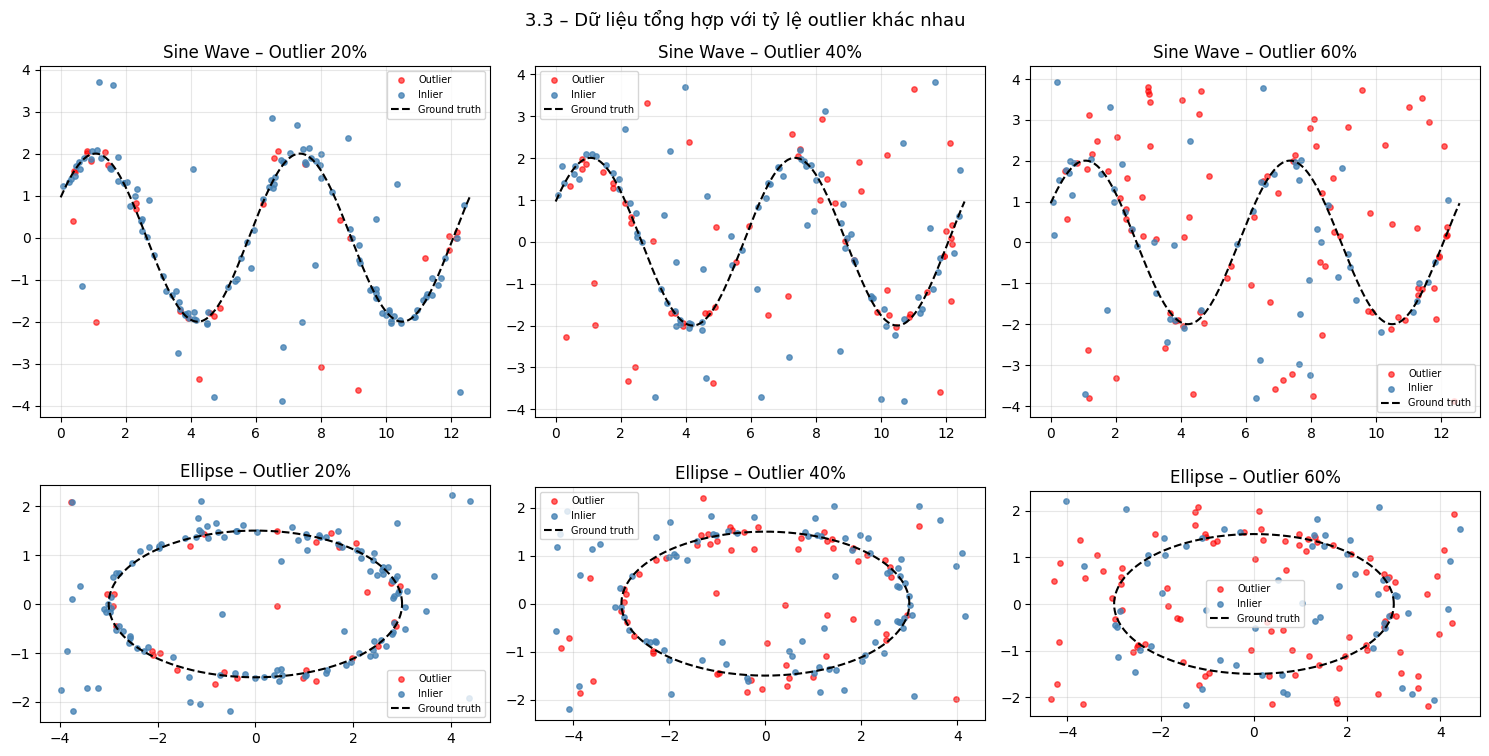

In [5]:
## Thử nghiệm với tỷ lệ outlier 20%, 40%, 60%

def make_dataset(generate_fn, outlier_ratio, n_total=100, **kwargs):
    """
    Tạo dataset với tỷ lệ outlier cho trước.
    n_total: tổng số điểm
    """
    n_in  = int(n_total * (1 - outlier_ratio))
    n_out = n_total - n_in
    return generate_fn(n_inliers=n_in, n_outliers=n_out, **kwargs)


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
outlier_ratios = [0.2, 0.4, 0.6]

# --- Hàng 1: Sine Wave ---
for col, ratio in enumerate(outlier_ratios):
    pts, true = make_dataset(generate_sine_data, ratio, n_total=150)
    n_in = int(150 * (1 - ratio))

    ax = axes[0][col]
    ax.scatter(pts[n_in:, 0], pts[n_in:, 1],
               c='red', s=15, alpha=0.6, label='Outlier')
    ax.scatter(pts[:n_in, 0], pts[:n_in, 1],
               c='steelblue', s=15, alpha=0.8, label='Inlier')

    x_plot = np.linspace(0, 4 * np.pi, 300)
    A, omega, phi = true
    ax.plot(x_plot, A * np.sin(omega * x_plot + phi),
            'k--', linewidth=1.5, label='Ground truth')

    ax.set_title(f'Sine Wave – Outlier {int(ratio*100)}%')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# --- Hàng 2: Ellipse ---
for col, ratio in enumerate(outlier_ratios):
    pts, true = make_dataset(generate_ellipse_data, ratio, n_total=150)
    n_in = int(150 * (1 - ratio))

    ax = axes[1][col]
    ax.scatter(pts[n_in:, 0], pts[n_in:, 1],
               c='red', s=15, alpha=0.6, label='Outlier')
    ax.scatter(pts[:n_in, 0], pts[:n_in, 1],
               c='steelblue', s=15, alpha=0.8, label='Inlier')

    cx, cy, a, b = true
    theta = np.linspace(0, 2 * np.pi, 300)
    ax.plot(cx + a * np.cos(theta), cy + b * np.sin(theta),
            'k--', linewidth=1.5, label='Ground truth')

    ax.set_title(f'Ellipse – Outlier {int(ratio*100)}%')
    ax.set_aspect('equal')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('3.3 – Dữ liệu tổng hợp với tỷ lệ outlier khác nhau', fontsize=13)
plt.tight_layout()
plt.show()

## 3.4 Số iteration

In [6]:
## Hàm tính số iteration

def compute_iterations(
        outlier_ratio,
        sample_size,
        p=0.99
):

    e = outlier_ratio
    s = sample_size

    numerator = np.log(1 - p)
    denominator = np.log(
        1 - (1 - e)**s
    )

    N = int(
        np.ceil(
            numerator / denominator
        )
    )

    return N

In [7]:
## Kiểm tra bảng trong PDF

outliers = [0.1, 0.3, 0.5, 0.7]

for e in outliers:

    N = compute_iterations(
        outlier_ratio=e,
        sample_size=2
    )

    print(
        f"Outlier={e*100:.0f}% "
        f"-> N={N}"
    )

Outlier=10% -> N=3
Outlier=30% -> N=7
Outlier=50% -> N=17
Outlier=70% -> N=49


## 3.5 Thực nghiệm

In [8]:
## Kiểm tra RANSAC thành công bao nhiêu %

def experiment(
        outlier_ratio,
        sample_size,
        epsilon,
        trials=100
):

    N = compute_iterations(
        outlier_ratio,
        sample_size
    )

    success = 0

    for _ in range(trials):

        n_out = int(
            100 * outlier_ratio
            / (1 - outlier_ratio)
        )

        points = generate_line_data(
            n_inliers=100,
            n_outliers=n_out
        )

        model, inliers = ransac(
            points,
            fit_line,
            line_distance,
            sample_size,
            epsilon,
            N
        )

        if len(inliers) > 80:
            success += 1

    return success / trials

In [9]:
## Chạy với N lý thuyết

for e in [0.2, 0.4, 0.6]:

    rate = experiment(
        e,
        sample_size=2,
        epsilon=0.6,
        trials=100
    )

    print(
        f"Outlier={e*100:.0f}% "
        f"Success={rate*100:.2f}%"
    )

NameError: name 'generate_line_data' is not defined

In [6]:
## Giảm N xuống

def experiment_with_custom_N(
        outlier_ratio,
        sample_size,
        epsilon,
        N,
        trials=100
):

    success = 0

    for _ in range(trials):

        n_out = int(
            100 * outlier_ratio
            / (1 - outlier_ratio)
        )

        points = generate_line_data(
            100,
            n_out
        )

        model, inliers = ransac(
            points,
            fit_line,
            line_distance,
            sample_size,
            epsilon,
            N
        )

        if len(inliers) > 80:
            success += 1

    return success / trials

In [7]:
## So sánh

e = 0.5

N_theory = compute_iterations(
    e,
    sample_size=2
)

for factor in [
        1.0,
        0.75,
        0.5,
        0.25
]:

    N = int(
        N_theory * factor
    )

    rate = experiment_with_custom_N(
        e,
        sample_size=2,
        epsilon=0.6,
        N=N
    )

    print(
        f"N={N} "
        f"Success={rate*100:.2f}%"
    )

NameError: name 'generate_line_data' is not defined

In [8]:
## Vẽ biểu đồ

Ns = []
rates = []

for factor in np.arange(
        0.2,
        1.2,
        0.1
):

    N = int(
        N_theory * factor
    )

    rate = experiment_with_custom_N(
        e,
        sample_size=2,
        epsilon=0.6,
        N=N
    )

    Ns.append(N)
    rates.append(rate)

plt.plot(
    Ns,
    rates,
    marker='o'
)

plt.xlabel(
    "Number of Iterations"
)

plt.ylabel(
    "Success Rate"
)

plt.title(
    "RANSAC Success vs Iterations"
)

plt.grid(True)

plt.show()

NameError: name 'generate_line_data' is not defined